<h1><center>Honeypot- AWS Data Analyze</center></h1>

In [1]:


import random
import folium
from folium.plugins import HeatMap

import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns

import matplotlib.pyplot as plt
import plotly.graph_objects as go
import matplotlib.ticker as ticker
import plotly.figure_factory as ff


# !pip install prophet # Install the prophet library
#from fbprophet import Prophet # import the Prophet class
# from fbprophet import Prophet
from pandas_datareader import data
from scipy import stats
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.seasonal import seasonal_decompose

from sklearn.preprocessing import MinMaxScaler

from matplotlib.ticker import FixedFormatter, FixedLocator

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("/content/AWS_Honeypot_marx-geo.csv")

In [3]:
month_list = ['Jan.', 'Feb.', 'Mar.', 'Apr.', 'May', 'June', 'July', 'Aug.', 'Sept.', 'Oct.', 'Nov.', 'Dec.']
attack_date = {"year": [], "month": [], "day": [], "time": [], "hour": []}

for d_date in df['datetime']:
    d_date = d_date.split('/')
    mon = d_date[0]
    day = d_date[1]

    year_time = d_date[2].split(' ')
    year = year_time[0]
    time = year_time[1]

    attack_date["year"].append(year)
    attack_date["month"].append(month_list[int(mon) + 1])
    attack_date["day"].append(day)
    attack_date["time"].append(time)
    attack_date["hour"].append(f"{time.split(':')[0]}h")

df["year"] = attack_date["year"]
df["month"] = attack_date["month"]
df["day"] = attack_date["day"]
df["time"] = attack_date["time"]
df["hour"] = attack_date["hour"]

In [4]:
df.head(20)

,datetime,host,src,proto,type,spt,dpt,srcstr,cc,country,...,localeabbr,postalcode,latitude,longitude,Unnamed: 15,year,month,day,time,hour
0,3/3/13 21:53,groucho-oregon,1032051418,TCP,NaN,6000.0,1433.0,61.131.218.218,CN,China,...,36,NaN,28.5500,115.9333,NaN,13,May,3,21:53,21h
1,3/3/13 21:57,groucho-oregon,1347834426,UDP,NaN,5270.0,5060.0,80.86.82.58,DE,Germany,...,NaN,NaN,51.0000,9.0000,NaN,13,May,3,21:57,21h
2,3/3/13 21:58,groucho-oregon,2947856490,TCP,NaN,2489.0,1080.0,175.180.184.106,TW,Taiwan,...,NaN,NaN,25.0392,121.5250,NaN,13,May,3,21:58,21h
3,3/3/13 21:58,groucho-us-east,841842716,UDP,NaN,43235.0,1900.0,50.45.128.28,US,United States,...,OR,97124,45.5848,-122.9117,NaN,13,May,3,21:58,21h
4,3/3/13 21:58,groucho-singapore,3587648279,TCP,NaN,56577.0,80.0,213.215.43.23,FR,France,...,NaN,NaN,48.8600,2.3500,NaN,13,May,3,21:58,21h
5,3/3/13 21:58,groucho-tokyo,3323217250,TCP,NaN,32628.0,2323.0,198.20.69.98,US,United States,...,IL,60661,41.8825,-87.6441,NaN,13,May,3,21:58,21h
6,3/3/13 21:59,groucho-oregon,3730416887,TCP,NaN,6000.0,1433.0,222.89.164.247,CN,China,...,41,NaN,34.6836,113.5325,NaN,13,May,3,21:59,21h
7,3/3/13 22:07,groucho-singapore,3738622573,TCP,NaN,6000.0,3306.0,222.214.218.109,CN,China,...,51,NaN,30.6667,104.0667,NaN,13,May,3,22:07,22h
8,3/3/13 22:12,groucho-oregon,3683919430,TCP,NaN,6000.0,1433.0,219.148.38.70,CN,China,...,13,NaN,39.8897,115.2750,NaN,13,May,3,22:12,22h
9,3/3/13 22:14,groucho-singapore,1007884304,TCP,NaN,6000.0,1433.0,60.19.24.16,CN,China,...,21,NaN,41.7922,123.4328,NaN,13,May,3,22:14,22h


In [5]:
def bar_plot_data(df: dict, field: str, subtitle: str, figsize=(5, 4), top_filter=15):
    fig, ax1 = plt.subplots(figsize=figsize, dpi=100)

    for spline in ['top', 'right', 'left']:
        ax1.spines[spline].set_visible(False)

    df_filter = df[field].value_counts().rename_axis(field).reset_index(name='counts')
    if top_filter:
        df_filter = df_filter.head(top_filter)
    sns.barplot(data=df_filter, palette='cool', x='counts', y=field)
    ax1.tick_params(axis='both', which='both', labelsize=12, bottom=True, left=False)
    ax1.set_xlabel(f'count', fontsize=13, color = '#333F4B')
    ax1.set_ylabel(f'{field}', fontsize=13, color = '#333F4B')

    plt.plot(color="white", lw=3)
    fig.suptitle(subtitle, fontsize=18)
    plt.show()

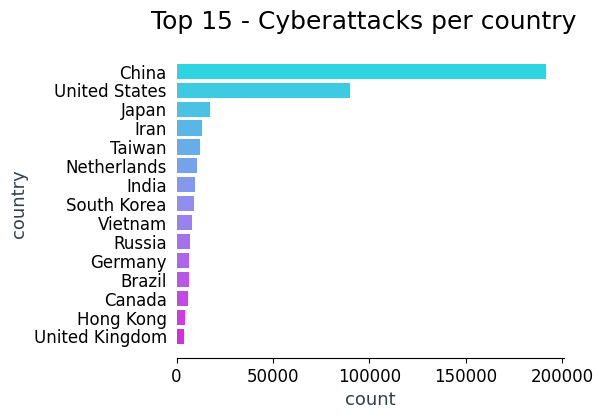

In [6]:
bar_plot_data(df, 'country', 'Top 15 - Cyberattacks per country')

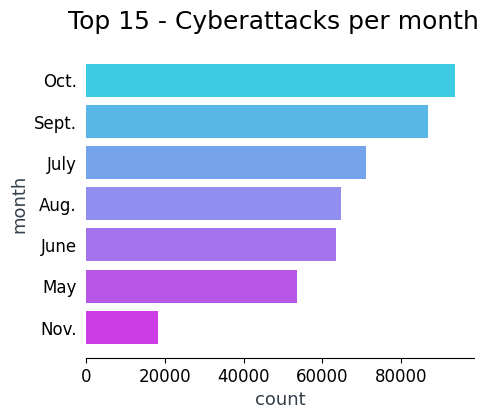

In [8]:
bar_plot_data(df, 'month', 'Top 15 - Cyberattacks per month')

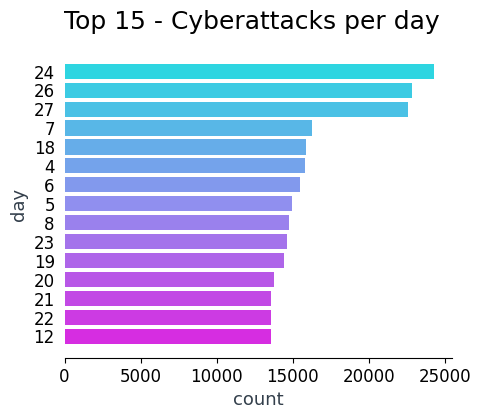

In [9]:
bar_plot_data(df, 'day', 'Top 15 - Cyberattacks per day')

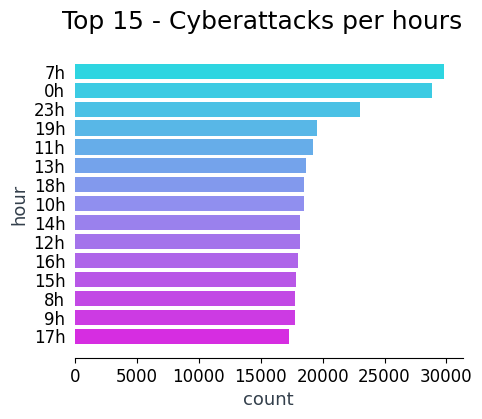

In [10]:
bar_plot_data(df, 'hour', 'Top 15 - Cyberattacks per hours')

In [11]:
df['srcstr'].value_counts().rename_axis('ipaddress').reset_index(name='counts')

,ipaddress,counts
0,175.146.199.252,18472
1,2.186.189.218,11116
2,203.178.148.19,7086
3,128.9.168.98,7046
4,129.82.138.44,6772
...,...,...
69597,113.161.81.118,1
69598,116.252.182.193,1
69599,113.81.65.41,1
69600,122.144.11.167,1


In [12]:
def get_pie_plot_count(df: dict, field: str, subtitle: str):
    fig, ax1 = plt.subplots(figsize=(10, 6), dpi=100)
    colors = sns.color_palette('cool')
    df_filter = df[field].value_counts().rename_axis(field).reset_index(name='counts')
    ax1.tick_params(axis='both', which='both', labelsize=12, bottom=True, left=False)
    plt.pie(df_filter['counts'], colors=colors, labels=df_filter[field], autopct = '%0.0f%%',
            startangle=90,  textprops={'fontsize': 14})

    plt.plot(color="white", lw=3)
    fig.suptitle(subtitle, fontsize=18)
    plt.show()

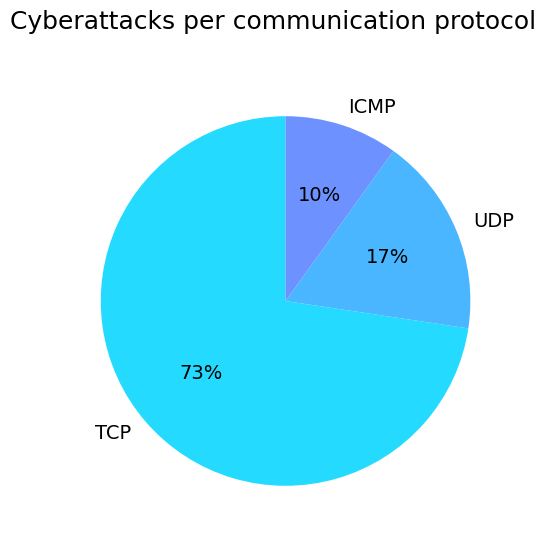

In [13]:
get_pie_plot_count(df, 'proto', 'Cyberattacks per communication protocol')

In [14]:
attack= df[['latitude','longitude']]
attack.latitude.fillna(0, inplace = True)
attack.longitude.fillna(0, inplace = True)

World =folium.Map(location=[0,0],zoom_start=2)
HeatMap(data=attack, radius=16).add_to(World)

print('Top cyberattacks by country')
World

Output hidden; open in https://colab.research.google.com to view.

In [15]:
def get_histplot_central_tendency(df: dict, fields: list):
    colors = sns.color_palette('cool')
    for field in fields:
        f, (ax1) = plt.subplots(figsize=(10, 5), dpi=100)
        v_dist_1 = df[field].values

        for spline in ['top', 'right', 'left']:
            ax1.spines[spline].set_visible(False)

        sns.histplot(v_dist_1, ax=ax1, palette=colors, kde=True)

        mean=df[field].mean()
        median=df[field].median()
        mode=df[field].mode().values[0]

        ax1.axvline(mean, color='r', linestyle='--', label="Mean")
        ax1.axvline(median, color='g', linestyle='-', label="Mean")
        ax1.axvline(mode, color='b', linestyle='-', label="Mode")
        ax1.tick_params(axis='both', which='both', labelsize=12, bottom=True, left=False)
        ax1.set_xlabel(f'count', fontsize=13, color = '#333F4B')
        ax1.set_ylabel(f'{field}', fontsize=13, color = '#333F4B')
        ax1.legend()
        plt.grid(False)
        plt.plot(color="white", lw=3)
        f.suptitle(f"Representation Histogram for {field}", fontsize=18)

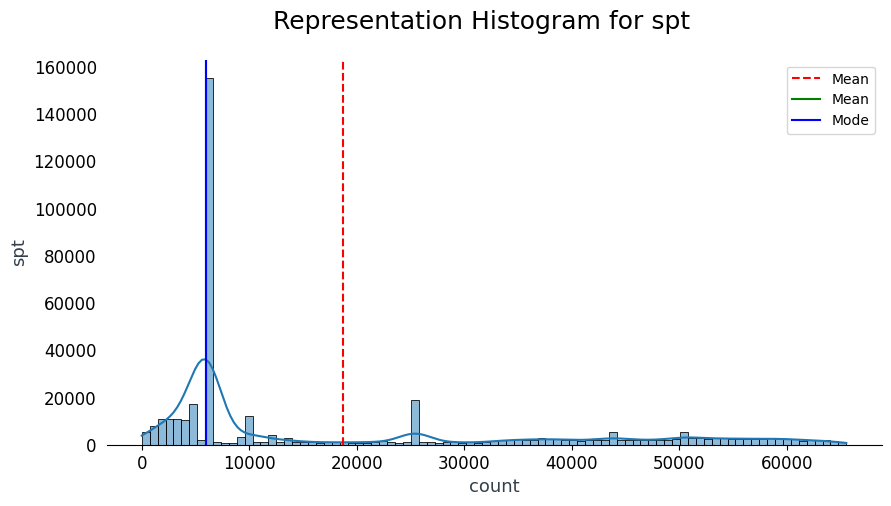

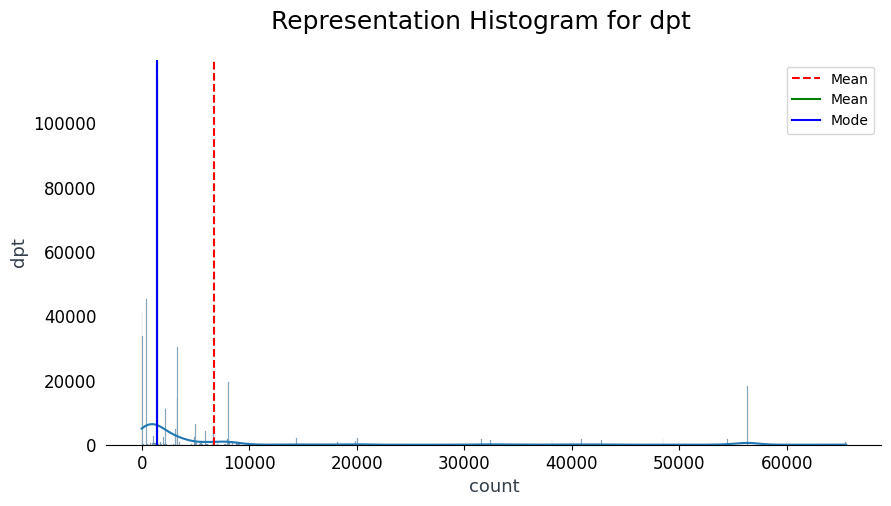

In [16]:
get_histplot_central_tendency(df, ['spt', 'dpt'])

In [ ]:
df['type'].value_counts().rename_axis('id_type_attack').reset_index(name='counts')

,id_type_attack,counts
0,8.0,38597
1,3.0,4251
2,11.0,1156
3,0.0,536
4,13.0,142
5,5.0,127
6,12.0,2


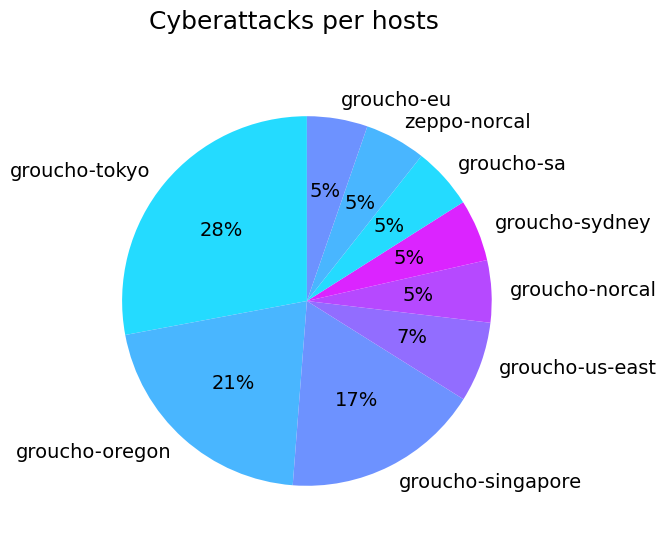

In [ ]:
get_pie_plot_count(df, 'host', 'Cyberattacks per hosts')

In [ ]:
df_filter = df[(df.host == "groucho-oregon") & (df.month == "May") & (df.hour == "20h")]
df_filter

,datetime,host,src,proto,type,spt,dpt,srcstr,cc,country,...,localeabbr,postalcode,latitude,longitude,Unnamed: 15,year,month,day,time,hour
1437,3/4/13 20:00,groucho-oregon,2036715561,TCP,NaN,27984.0,22.0,121.101.208.41,CN,China,...,11,NaN,39.9289,116.3883,NaN,13,May,4,20:00,20h
1441,3/4/13 20:05,groucho-oregon,3736745024,TCP,NaN,6000.0,1433.0,222.186.52.64,CN,China,...,32,NaN,32.0617,118.7778,NaN,13,May,4,20:05,20h
1442,3/4/13 20:06,groucho-oregon,3658020275,TCP,NaN,6000.0,1433.0,218.8.245.179,CN,China,...,23,NaN,45.7500,126.6500,NaN,13,May,4,20:06,20h
1444,3/4/13 20:08,groucho-oregon,3630406730,TCP,NaN,6000.0,1433.0,216.99.156.74,US,United States,...,CA,91789,34.0115,-117.8535,NaN,13,May,4,20:08,20h
1445,3/4/13 20:09,groucho-oregon,1019141837,TCP,NaN,6000.0,1433.0,60.190.222.205,CN,China,...,NaN,NaN,35.0000,105.0000,NaN,13,May,4,20:09,20h
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53246,3/31/13 20:46,groucho-oregon,1995742862,TCP,NaN,6000.0,1433.0,118.244.158.142,CN,China,...,11,NaN,39.9289,116.3883,NaN,13,May,31,20:46,20h
53248,3/31/13 20:49,groucho-oregon,3736734735,TCP,NaN,6000.0,1433.0,222.186.12.15,CN,China,...,32,NaN,32.0617,118.7778,NaN,13,May,31,20:49,20h
53249,3/31/13 20:49,groucho-oregon,3689613428,TCP,NaN,6000.0,1433.0,219.235.8.116,CN,China,...,11,NaN,39.9289,116.3883,NaN,13,May,31,20:49,20h
53258,3/31/13 20:52,groucho-oregon,3683824005,TCP,NaN,6000.0,1433.0,219.146.177.133,CN,China,...,37,NaN,36.6683,116.9972,NaN,13,May,31,20:52,20h


In [ ]:
df_filter['proto'].value_counts()

,count
proto,
TCP,392
UDP,35
ICMP,15


In [ ]:
import networkx as nx

G = nx.Graph()
G.add_node('groucho-oregon', color='red')

ip_listx = []
edge_color = []
for ip, proto in zip(df_filter['srcstr'], df_filter['proto']):
    if ip not in ip_listx:
        if 'TCP' == proto:
            edge_color.append('green')
        if 'UDP' == proto:
            edge_color.append('red')
        if 'ICMP' == proto:
            edge_color.append('orange')
        G.add_node(ip)
        ip_listx.append(ip)

for ip in ip_listx:
    G.add_edge('groucho-oregon', ip)
fig = plt.figure(1, figsize=(25, 25), dpi=100)
print('TPC == green\nUDP == red\nICMP == orange')
nx.draw(G, with_labels=True, font_weight='normal', edge_color=edge_color, arrowsize=30, arrowstyle='fancy')

Output hidden; open in https://colab.research.google.com to view.

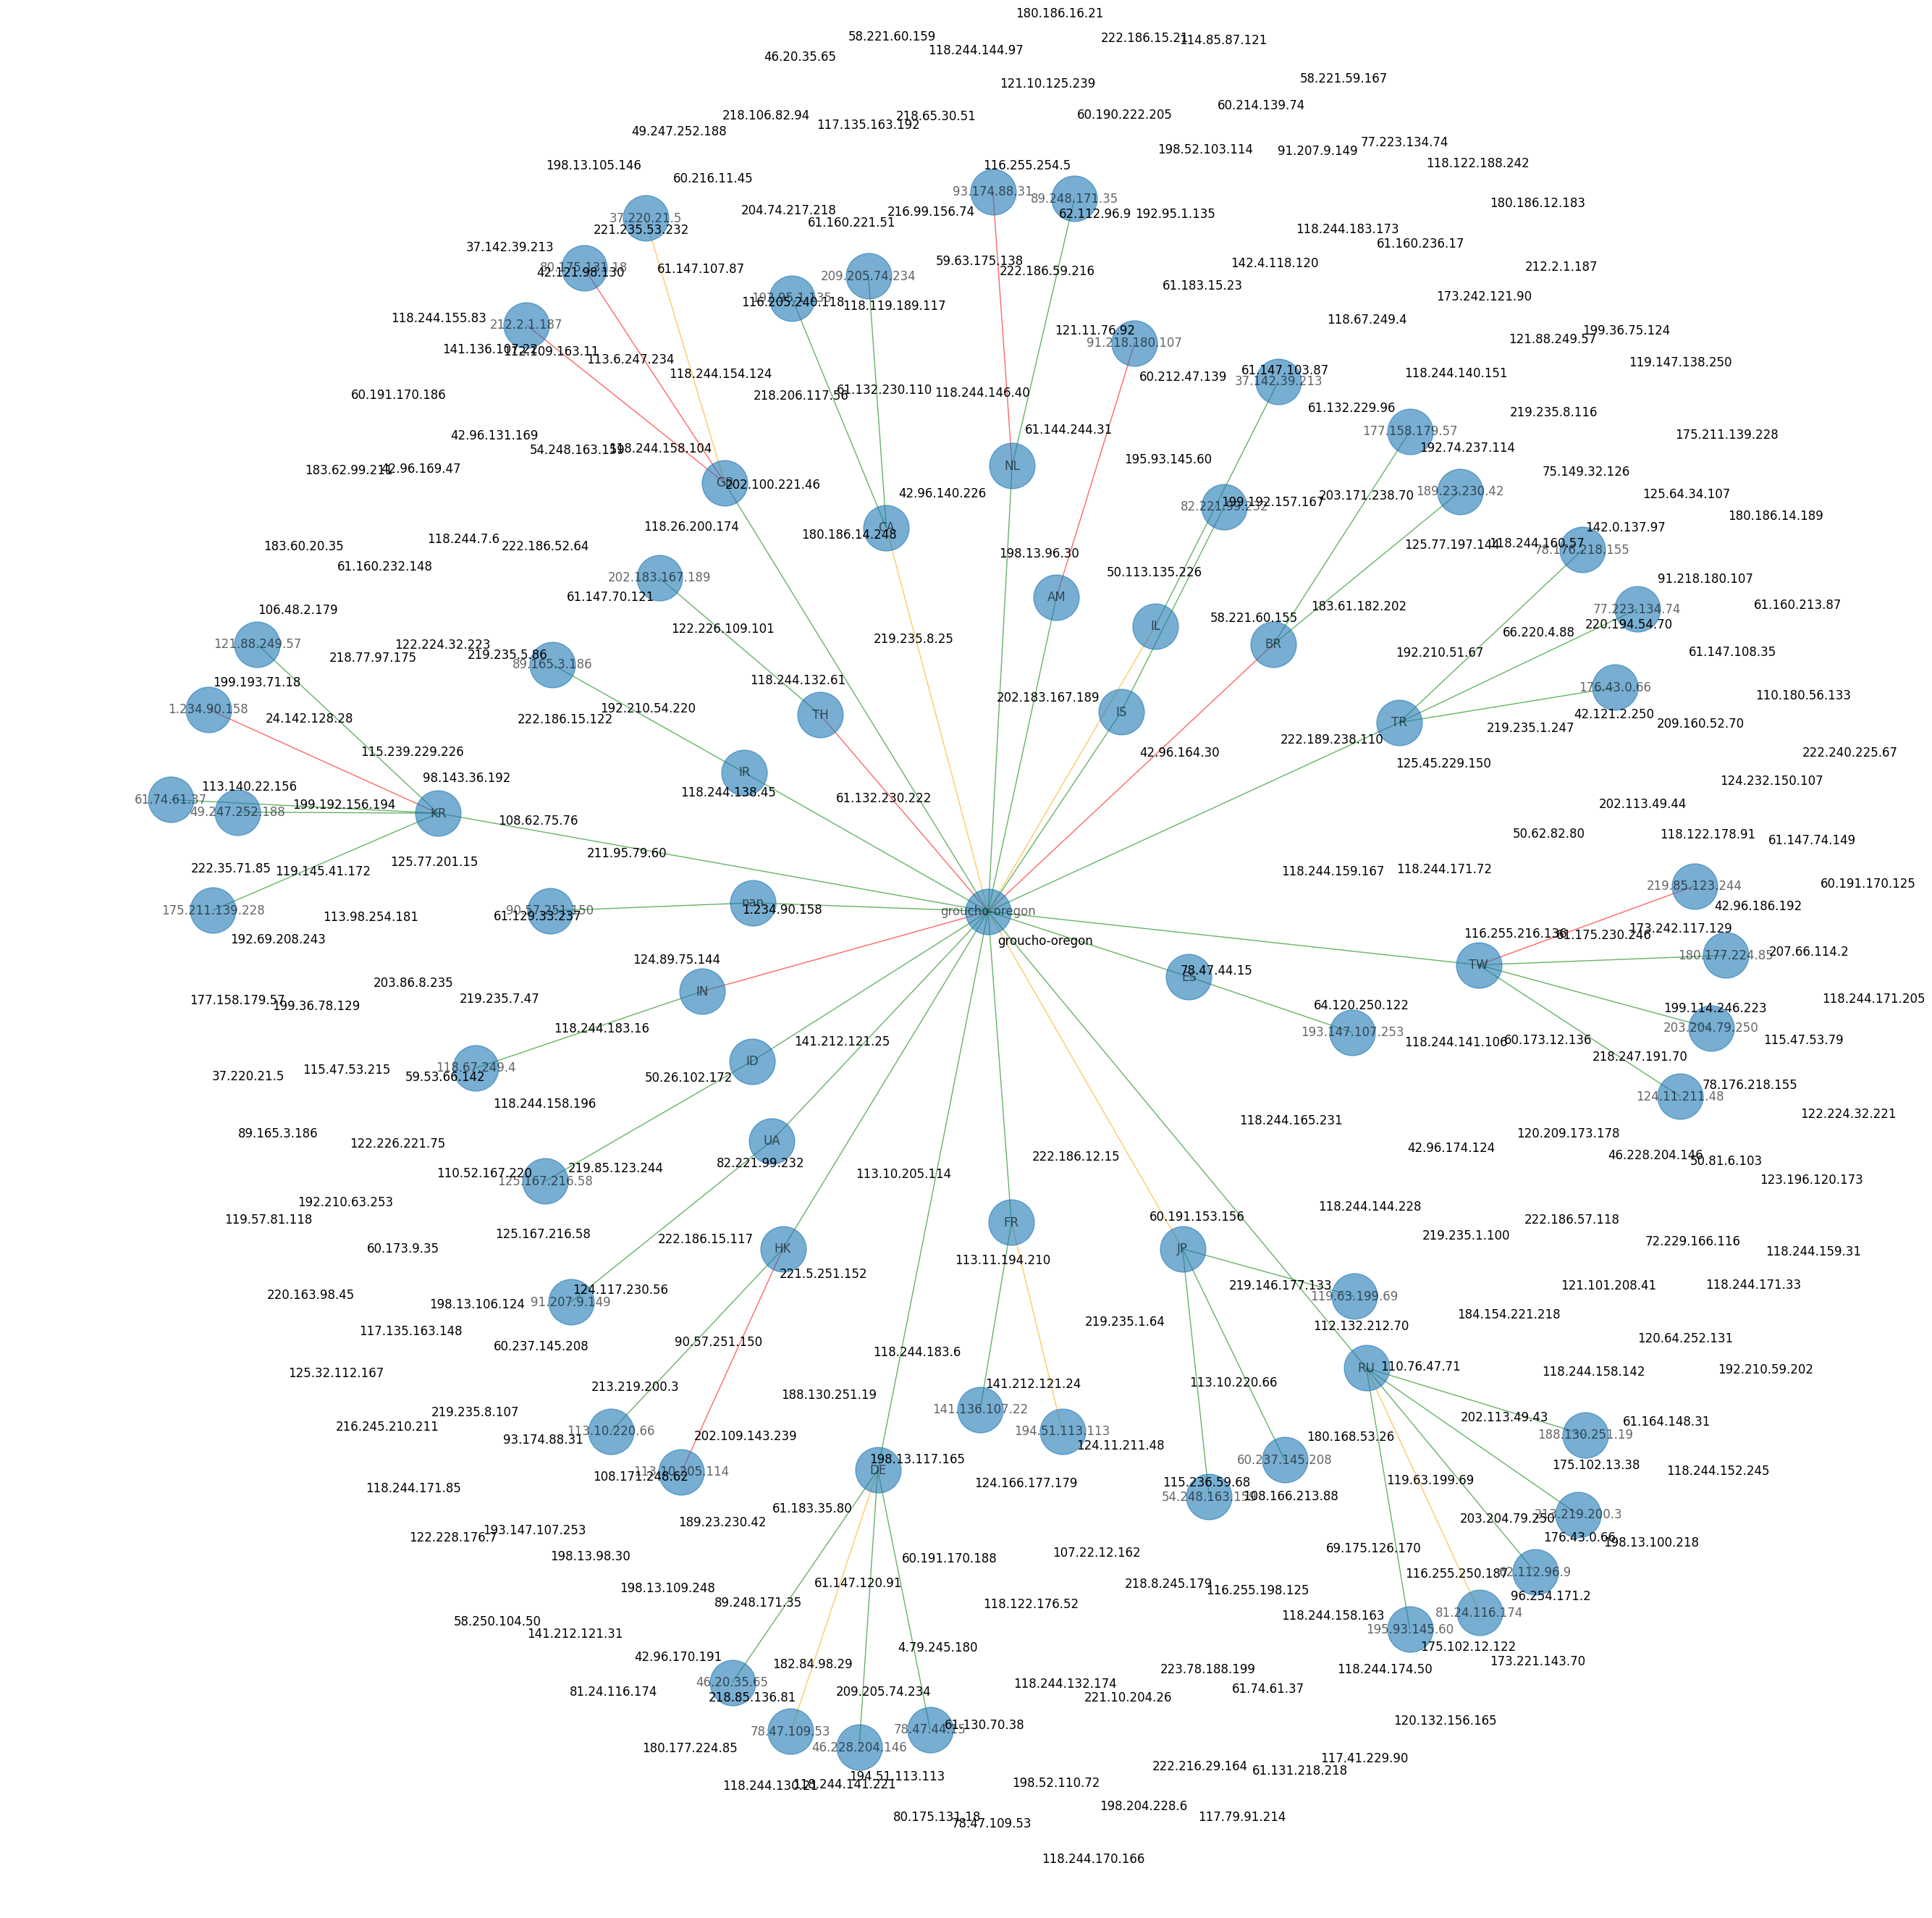

In [ ]:
from matplotlib.pyplot import figure, text

Gx = nx.Graph()
Gx.add_node('groucho-oregon')

country_list = []
ip_list = []
edge_color = []
for country, ip, proto in zip(df_filter['cc'], df_filter['srcstr'], df_filter['proto']):
    if country != 'CN' and country != 'US':
        if country not in country_list:
            Gx.add_node(country)
            country_list.append(country)

        if ip not in ip_list:
            if 'TCP' == proto:
                edge_color.append('green')
            if 'UDP' == proto:
                edge_color.append('red')
            if 'ICMP' == proto:
                edge_color.append('orange')

            Gx.add_node(ip)
            Gx.add_edge(country, ip)
            ip_list.append(ip)


for country in country_list:
    Gx.add_edge('groucho-oregon', country)

options = {
    "node_color": "black",
    "node_size": 50,
    "linewidths": 0,
    "width": 0.1,
}


pos = nx.spring_layout(G)
d = dict(G.degree)
fig = plt.figure(figsize=(26, 26), dpi=100)
nx.draw(Gx, alpha=0.6, node_size=2050, with_labels=True, font_weight='normal',
        edge_color=edge_color, arrowsize=30, arrowstyle='fancy')

for node, (x, y) in pos.items():
    text(x, y, node, fontsize=12)